Колонки:
 ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Информация о данных:

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 10/03/2004 18:00:00 to 04/04/2005 14:00:00
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    8991 non-null   object 
 2   NMHC(GT)       914 non-null    float64
 3   C6H6(GT)       8991 non-null   object 
 4   PT08.S2(NMHC)  8991 non-null   object 
 5   NOx(GT)        7718 non-null   object 
 6   PT08.S3(NOx)   8991 non-null   object 
 7   NO2(GT)        7715 non-null   object 
 8   PT08.S4(NO2)   8991 non-null   object 
 9   PT08.S5(O3)    8991 non-null   object 
 10  T              8991 non-null   object 
 11  RH             8991 non-null   object 
 12  AH             8991 non-null   object 
dtypes: float64(2),

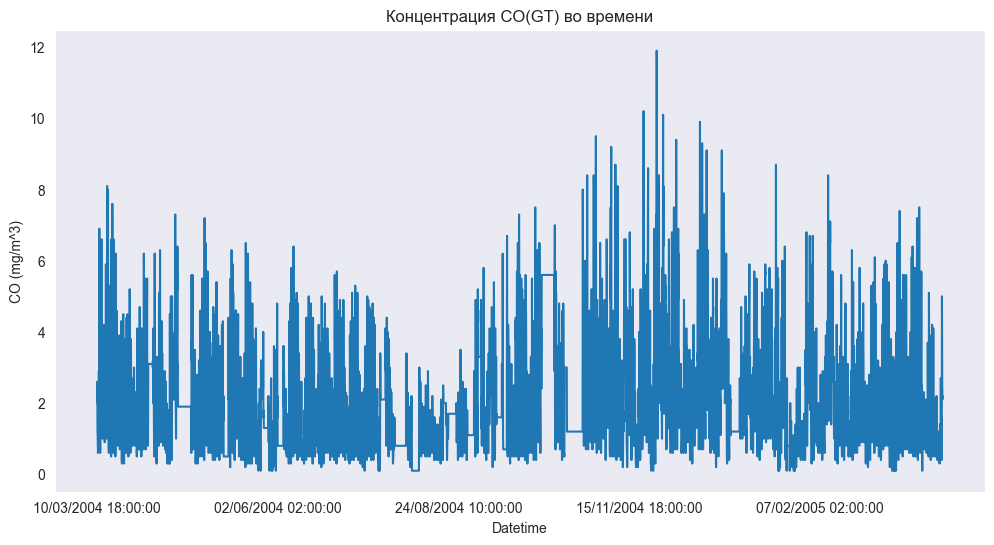

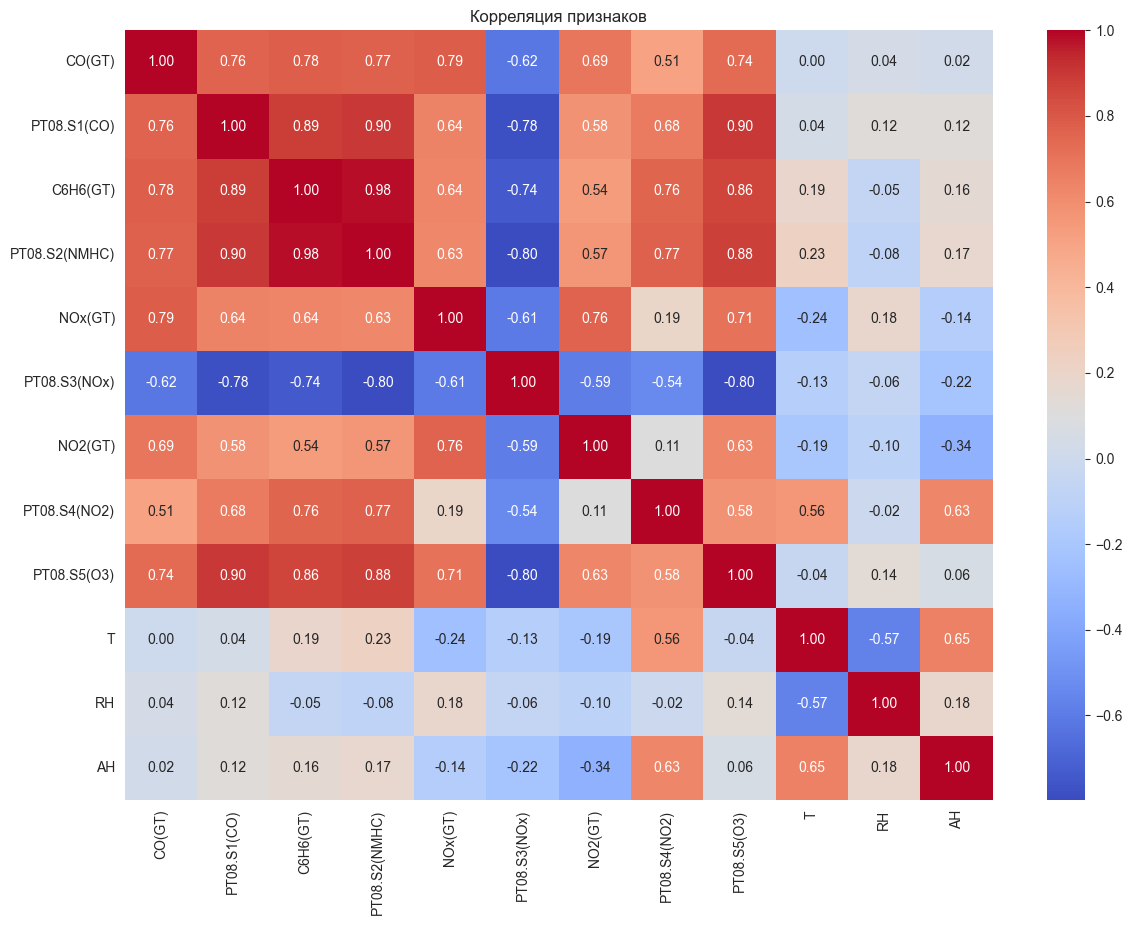

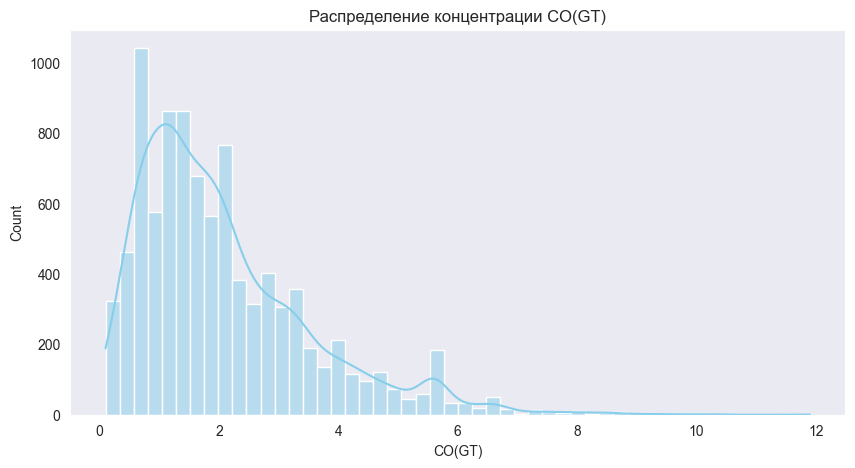

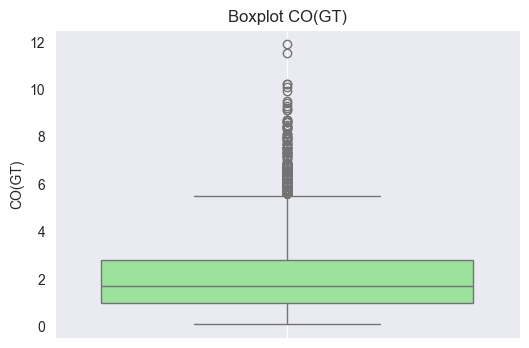

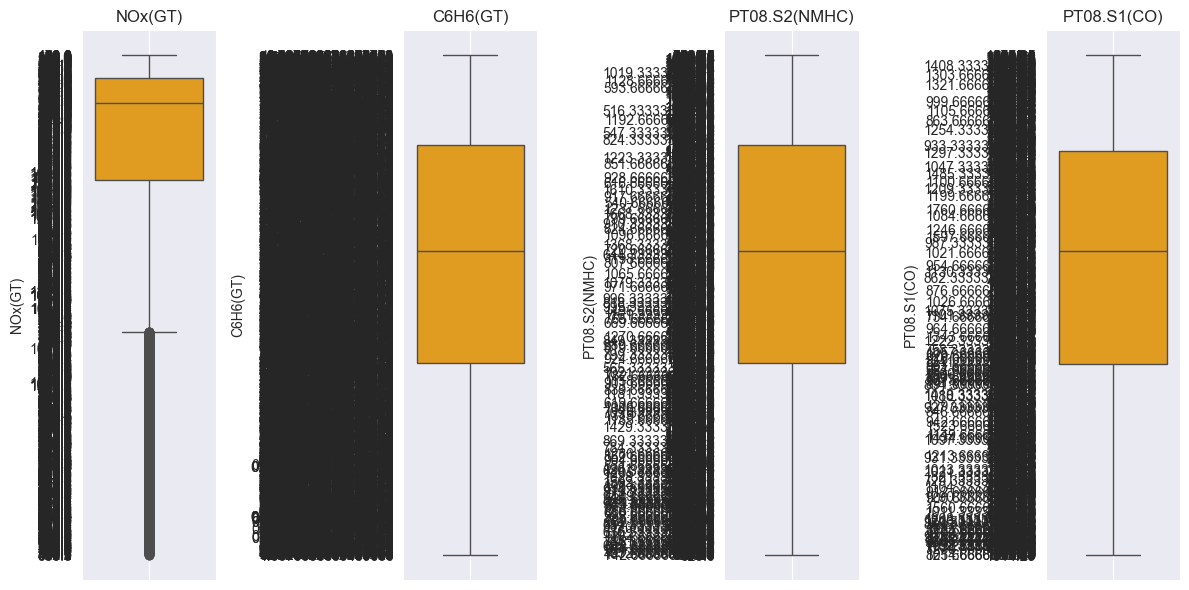

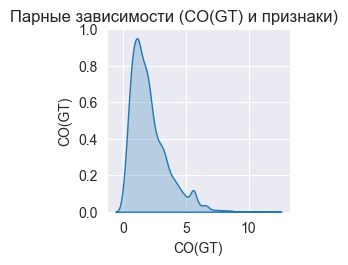

Обучение модели: Random Forest
Обучение модели: Gradient Boosting
Обучение модели: XGBoost
Обучение модели: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000297 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 7485, number of used features: 11
[LightGBM] [Info] Start training from score 2.080214
Обучение модели: CatBoost

Результаты моделей:
               Model      RMSE       MAE        R2
4           CatBoost  0.466747  0.291078  0.905510
0      Random Forest  0.481691  0.281620  0.899362
2            XGBoost  0.488350  0.299405  0.896560
3           LightGBM  0.488557  0.304526  0.896473
1  Gradient Boosting  0.544778  0.352559  0.871274
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bin

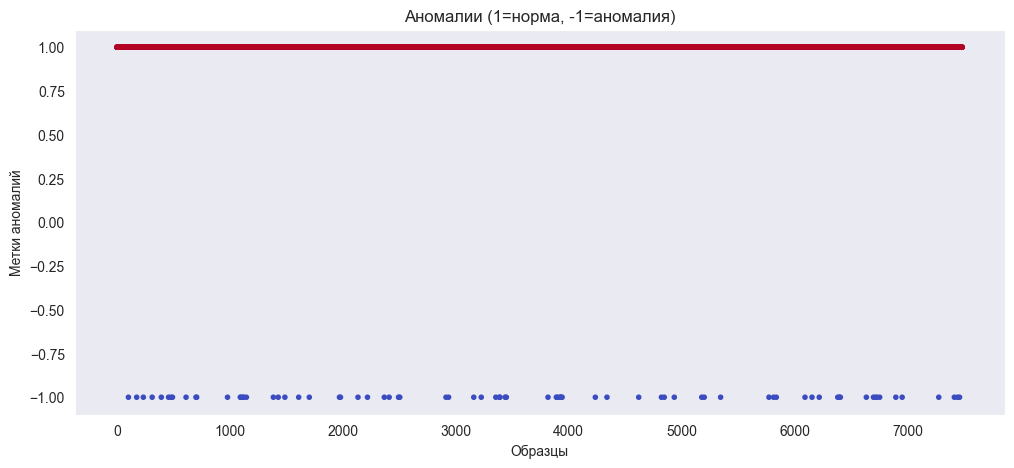

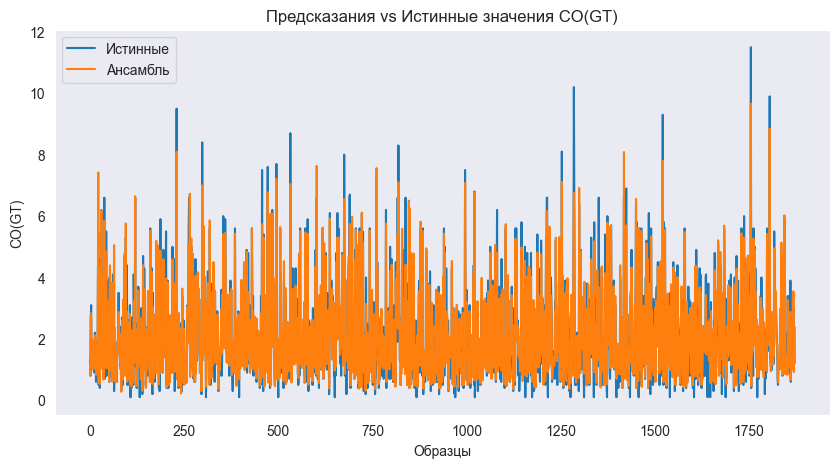

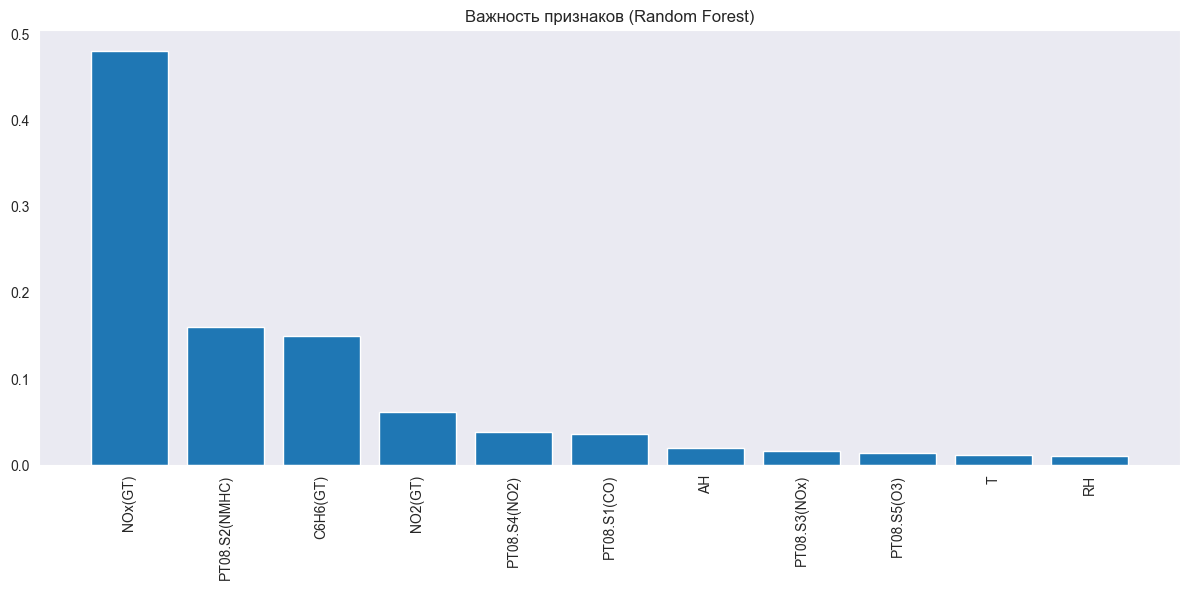


Сравнение первых 10 предсказаний:
+---+-------------------+-------------------------+
|   | Истинное значение | Предсказание (Ансамбль) |
+---+-------------------+-------------------------+
| 0 |        1.3        |   1.1976132853630124    |
| 1 |        0.8        |   0.8079613954355583    |
| 2 |        2.6        |   2.7310064132453236    |
| 3 |        3.1        |    2.833974782863855    |
| 4 |        1.3        |   1.7721717039055727    |
| 5 |        1.2        |   1.2037553278624191    |
| 6 |        1.4        |   1.5058631651708516    |
| 7 |        1.8        |   1.9690136509217457    |
| 8 |        1.1        |   1.2053149661190772    |
| 9 |        1.0        |   1.0150671641592608    |
+---+-------------------+-------------------------+


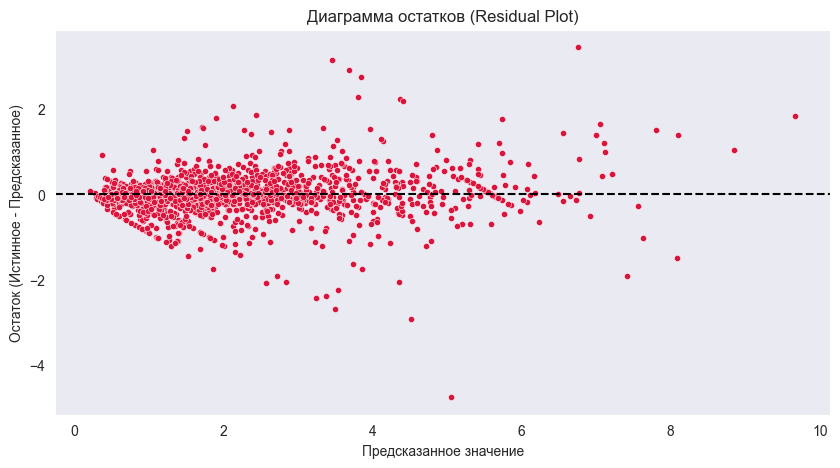

In [1]:
# 1. Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, IsolationForest
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

# 2. Загрузка и предобработка данных
url = "https://raw.githubusercontent.com/PacktPublishing/Time-Series-Analysis-with-Python-Cookbook/main/datasets/Ch2/AirQualityUCI.csv"
df = pd.read_csv(url, sep=';', decimal=',', parse_dates=[[0, 1]], na_values=-200)
df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], errors='ignore', inplace=True)
df.rename(columns={"Date_Time": "Datetime"}, inplace=True)
df.columns = df.columns.str.strip()
df.set_index("Datetime", inplace=True)
df['CO(GT)'] = pd.to_numeric(df['CO(GT)'], errors='coerce')

print("Колонки:\n", df.columns.tolist())
print("\nИнформация о данных:\n")
print(df.info())

print("\nПервые 10 записей таблицы:")
print(tabulate(df.head(10), headers='keys', tablefmt='pretty'))

# 3. Очистка
print("\nДо очистки:", df.shape)
df.dropna(thresh=int(len(df) * 0.7), axis=1, inplace=True)
df.fillna(method='ffill', inplace=True)
df.dropna(inplace=True)
print("После очистки:", df.shape)

# 4. EDA
plt.figure(figsize=(12, 6))
df['CO(GT)'].plot(title="Концентрация CO(GT) во времени")
plt.ylabel("CO (mg/m^3)")
plt.grid()
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляция признаков")
plt.show()

# Доп. визуализации
plt.figure(figsize=(10, 5))
sns.histplot(df['CO(GT)'], bins=50, kde=True, color='skyblue')
plt.title("Распределение концентрации CO(GT)")
plt.xlabel("CO(GT)")
plt.grid()
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(y=df['CO(GT)'], color='lightgreen')
plt.title("Boxplot CO(GT)")
plt.grid()
plt.show()

top_corr = df.corr()['CO(GT)'].abs().sort_values(ascending=False)[1:5].index.tolist()
plt.figure(figsize=(12, 6))
for i, col in enumerate(top_corr, 1):
    plt.subplot(1, len(top_corr), i)
    sns.boxplot(y=df[col], color='orange')
    plt.title(col)
    plt.grid()
plt.tight_layout()
plt.show()

# Pairplot
high_corr_features = df.corr()['CO(GT)'].abs().sort_values(ascending=False)[1:4].index.tolist()
sns.pairplot(df[[*high_corr_features, 'CO(GT)']], diag_kind='kde')
plt.suptitle("Парные зависимости (CO(GT) и признаки)", y=1.02)
plt.show()

# 5. Подготовка данных
features = df.drop(columns=['CO(GT)']).columns
X = df[features]
y = df['CO(GT)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Модели
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42)
}

results = []
for name, model in models.items():
    print(f"Обучение модели: {name}")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

df_results = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("\nРезультаты моделей:")
print(df_results)

# 7. Ансамбль
ensemble = VotingRegressor(estimators=[(name, model) for name, model in models.items()])
ensemble.fit(X_train_scaled, y_train)
y_ens_pred = ensemble.predict(X_test_scaled)
print(f"\nАнсамбль R2: {r2_score(y_test, y_ens_pred):.4f}")

# 8. Аномалии
iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(X_train_scaled)
plt.figure(figsize=(12, 5))
plt.scatter(range(len(outliers)), outliers, c=outliers, cmap='coolwarm', marker='.')
plt.title("Аномалии (1=норма, -1=аномалия)")
plt.xlabel("Образцы")
plt.ylabel("Метки аномалий")
plt.grid()
plt.show()

# 9. Визуализация ошибок и примеры предсказаний
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Истинные')
plt.plot(y_ens_pred, label='Ансамбль')
plt.title("Предсказания vs Истинные значения CO(GT)")
plt.xlabel("Образцы")
plt.ylabel("CO(GT)")
plt.legend()
plt.grid()
plt.show()

# Важность признаков (Random Forest)
rf = models['Random Forest']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Важность признаков (Random Forest)")
plt.bar(range(len(features)), importances[indices], align='center')
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.grid()
plt.show()

# Таблица сравнения предсказаний
comparison_df = pd.DataFrame({
    "Истинное значение": y_test.values,
    "Предсказание (Ансамбль)": y_ens_pred
})
print("\nСравнение первых 10 предсказаний:")
print(tabulate(comparison_df.head(10), headers='keys', tablefmt='pretty'))

# Диаграмма остатков
residuals = y_test - y_ens_pred
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_ens_pred, y=residuals, color='crimson', s=20)
plt.axhline(0, color='black', linestyle='--')
plt.title("Диаграмма остатков (Residual Plot)")
plt.xlabel("Предсказанное значение")
plt.ylabel("Остаток (Истинное - Предсказанное)")
plt.grid()
plt.show()
